# DSA 5102 - Programming Assignment 1


## Description

As the first homework of this course, you will apply the knowledge you have learned in the first lecture on `linear models` and simple extensions using `kernel` methods on some datasets. This is also a chance to learn to use `jupyter notebook` and basic `sklearn` functionalities. A basic introduction to installing and using `jupyter notebooks` is found [here](https://www.datacamp.com/community/tutorials/tutorial-jupyter-notebook). You are strongly encouraged to use python 3 instead of python 2


The goals of this homework are
  * Learn basic data processing and machine learning using python
  * Reinforce knowledge on linear models and kernel methods
  * Prepare for the project in this course
  
Whenever you are stuck, you are encouraged to look at the jupyter notebook demonstration for the first lecture for some guidance. You should also learn to look at documentation of online libraries. For example, if you want to perform *kernel ridge regression* using `sklearn`, a quick google will land you on [this page](https://scikit-learn.org/stable/modules/kernel_ridge.html), where extensive description and examples are given.

## Instructions

Please complete each question below directly in this notebook. Note that you can write in the cells to describe what you are doing and any issues you face. If you are familiar, you can also format it using `markdown` as it is supported by `jupyter`. 

The grade given is based on the following
  1. Scientific correctness of your approach
  2. Clear documentation of your approach

## Dataset

We will work on the [Energy Efficiency dataset](https://archive.ics.uci.edu/dataset/242/energy%2Befficiency) from the UCI Machine Learning Repository. The data describe 768 simulated residential building configurations. For this assignment, the goal is to predict **heating load** from eight building design properties:

1. `Relative_Compactness`
2. `Surface_Area`
3. `Wall_Area`
4. `Roof_Area`
5. `Overall_Height`
6. `Orientation`
7. `Glazing_Area`
8. `Glazing_Area_Distribution`

The original UCI dataset contains both heating-load and cooling-load responses. The supplied `energy_efficiency_heating.csv` retains the eight input variables and `Heating_Load` only, so the response is the last column. The dataset contains no missing values. Place the CSV file in the same folder as this notebook.

Dataset citation: Tsanas, A. & Xifara, A. (2012). *Energy Efficiency* [Dataset]. UCI Machine Learning Repository. [https://doi.org/10.24432/C51307](https://doi.org/10.24432/C51307). Licensed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).


In [1]:
import pandas as pd


In [ ]:
data = pd.read_csv('./energy_efficiency_heating.csv')



In [4]:
data.head()


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


## Question 1 (2 points)

In this homework we are going to predict the last column values (`Heating_Load`) from design variables in the other columns. Choose 3 input properties and visualize each of their effects on the heating load. Plot your findings below. You may find the `seaborn` library examples in lecture 1 useful.


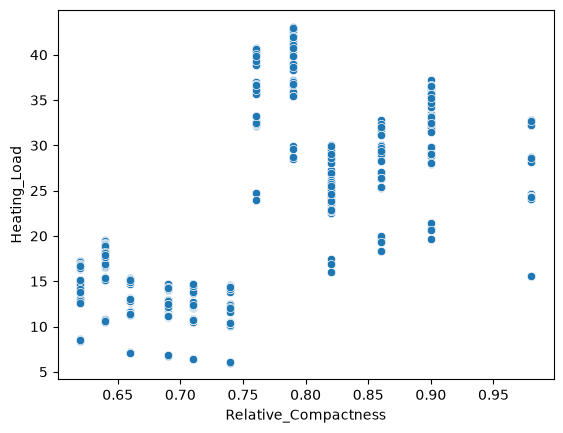

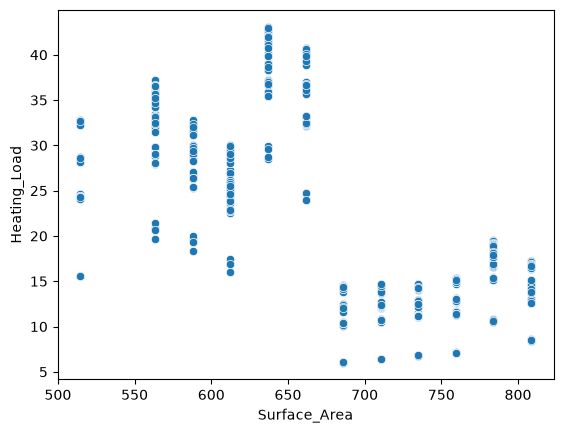

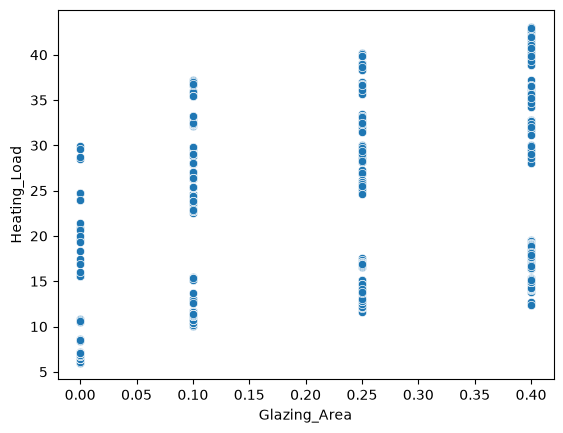

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=data, x='Relative_Compactness', y='Heating_Load')
plt.show()

sns.scatterplot(data=data, x='Surface_Area', y='Heating_Load')
plt.show()

sns.scatterplot(data=data, x='Glazing_Area', y='Heating_Load')
plt.show()

1. Heating load generally increases as relative compactness increases, although the relationship is not perfectly linear.
2. Heating load generally decreases as surface area increases, although the relationship is not perfectly linear.
3. Heating load generally increases as glazing area increases. However, heating load can be very different even when the glazing area is the same, which suggests that other properties also affect heating load.

## Question 2 (4 points)

Perform linear regression using all the input variables on this dataset to predict the heating load. Carefully evaluate your regression model using appropriate metrics and datasets.


In [11]:
X = data.drop(columns=['Heating_Load'])
y = data['Heating_Load']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=5102
)

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 8.960830406729787
RMSE: 2.9934646159141063
R2: 0.9140590167511907


The linear regression model perform well on the test set, the R^2 is about 91% that shows the model explains 91% of the variation in heating load. But the model still have space to improve.

## Question 3 (4 points)

Now, instead of linear regression, apply kernel ridge regression (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.kernel_ridge.KernelRidge.html)) with 3 kernels:
1. Linear kernel
2. Polynomial kernel with degree 3
3. RBF (Gaussian) kernel

Quantify the performance improvement (if any) with respect to the linear case, and also the other kernels. What do you observe? Which would you choose?

*Hint: For the RBF kernel, should you do something to the inputs first? Why?*

---

Note: we have not gone through cross validation and hyper-parameter tuning yet, so you are not expected to do this here -- although you are free to do it if you know how.


In [12]:
from sklearn.kernel_ridge import KernelRidge

1. Linear Kernel

In [24]:
krr_linear = KernelRidge(kernel='linear')
krr_linear.fit(X_train, y_train)

pred_linear = krr_linear.predict(X_test)

mse_krr_linear = mean_squared_error(y_test, pred_linear)
rmse_krr_linear = np.sqrt(mse_krr_linear)
r2_krr_linear = r2_score(y_test, pred_linear)

2. Polynomial kernel with degree 3

In [18]:
krr_poly = KernelRidge(kernel='polynomial', degree=3)
krr_poly.fit(X_train, y_train)

pred_poly = krr_poly.predict(X_test)

mse_krr_poly = mean_squared_error(y_test, pred_poly)
rmse_krr_poly = np.sqrt(mse_krr_poly)
r2_krr_poly = r2_score(y_test, pred_poly)

/opt/anaconda3/envs/dsa5102/lib/python3.12/site-packages/sklearn/linear_model/_ridge.py:266: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


3. RBF kernel

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

krr_rbf = KernelRidge(kernel='rbf')
krr_rbf.fit(X_train_scaled, y_train)

pred_rbf = krr_rbf.predict(X_test_scaled)

mse_krr_rbf = mean_squared_error(y_test, pred_rbf)
rmse_krr_rbf = np.sqrt(mse_krr_rbf)
r2_krr_rbf = r2_score(y_test, pred_rbf)

In [25]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "KRR Linear",
        "KRR Polynomial degree 3",
        "KRR RBF"
    ],
    "MSE": [
        mse,
        mse_krr_linear,
        mse_krr_poly,
        mse_krr_rbf
    ],
    "RMSE": [
        rmse,
        rmse_krr_linear,
        rmse_krr_poly,
        rmse_krr_rbf
    ],
    "R²": [
        r2,
        r2_krr_linear,
        r2_krr_poly,
        r2_krr_rbf
    ]
})

results

,Model,MSE,RMSE,R²
0,Linear Regression,8.960830,2.993465,0.914059
1,KRR Linear,8.769476,2.961330,0.915894
2,KRR Polynomial degree 3,0.830135,0.911117,0.992038
3,KRR RBF,6.016178,2.452790,0.942300


The polynomial kernel with degree 3 has the best performance. It has the lowest RMSE of 0.911 and the highest R² of 0.992. Both the polynomial and RBF kernels perform better than the linear models, which suggests that there are nonlinear relationships in the data. Therefore, I would choose the polynomial kernel with degree 3.